In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# プロジェクトのsrcディレクトリをimportパスに追加
import os
import sys

output_path = os.path.abspath(os.path.join('..', 'output/sis01/ER/single_rho0'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [17]:
params_df = pd.read_csv(os.path.join(output_path, "parameters.csv"))

display(params_df)

,networkType,N,k_ave,lambdaMin,lambdaMax,dlambda,gamma,rho01,c0,c1,c2,c3,tmax,batchNum,itrPerBatch
0,ER,10000,10,0.0,0.1,0.01,1.0,0.0001,0.0,0.1,0.2,0.6,200,40,5


In [18]:
network_type = params_df["networkType"].values[0]
N = params_df["N"].values[0]
k_ave = params_df["k_ave"].values[0]
lambda_min = params_df["lambdaMin"].values[0]
lambda_max = params_df["lambdaMax"].values[0]
dlambda = params_df["dlambda"].values[0]
gamma = params_df["gamma"].values[0]
rho01 = params_df["rho01"].values[0]
c0 = params_df["c0"].values[0]
c1 = params_df["c1"].values[0]
c2 = params_df["c2"].values[0]
c3 = params_df["c3"].values[0]
tmax = params_df["tmax"].values[0]
batch_num = params_df["batchNum"].values[0]
itr_per_batch = params_df["itrPerBatch"].values[0]

In [19]:
lambda_values = np.arange(lambda_min, lambda_max + dlambda, dlambda)
rho0_values = np.array([rho01])
c_values = np.array([c0, c1, c2, c3])
# c_values = np.array([c0, c1, c2])

exist_batch_idx = []
for batch_idx in range(batch_num):
    file_name = os.path.join(output_path, f"results_{batch_idx}.csv")
    if os.path.exists(file_name):
        exist_batch_idx.append(batch_idx)

total_itr = len(exist_batch_idx) * itr_per_batch

shape = (len(c_values), len(lambda_values), len(rho0_values), total_itr, tmax+1)
len_per_state = len(c_values) * len(lambda_values) * len(rho0_values) * itr_per_batch * (tmax + 1)
I = np.zeros(shape)

for idx, batch_idx in enumerate(exist_batch_idx):
    file_name = os.path.join(output_path, f"results_{batch_idx}.csv")
    print(f"Downloading {(idx + 1):02d} th file ...")
    values = np.loadtxt(file_name, delimiter=",", skiprows=1)
    reshaped = values.reshape((1, len(c_values), len(lambda_values), len(rho0_values), itr_per_batch, tmax+1))

    I[:, :, :, idx * itr_per_batch:(idx + 1) * itr_per_batch, :] = reshaped

IndexError: index 26 is out of bounds for axis 0 with size 11

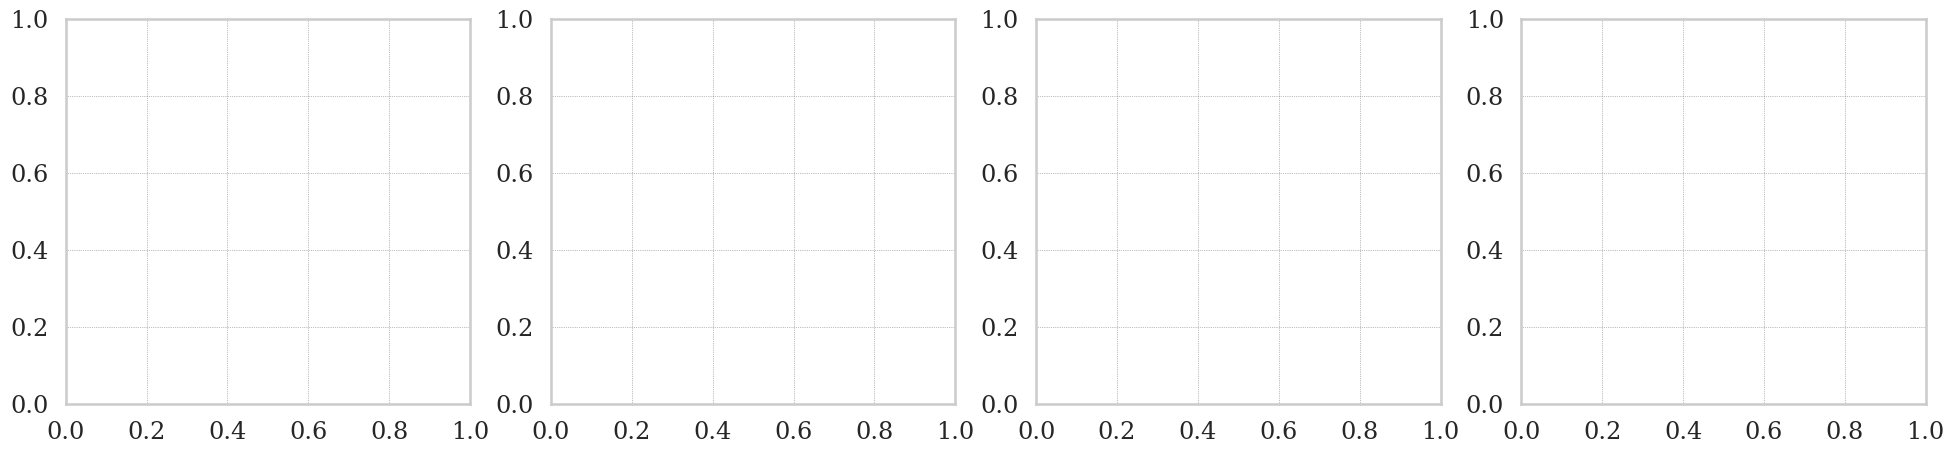

In [20]:
times = np.arange(tmax + 1)
lambda_idx = 26
rho0_idx = 0

c_idx_list = [0, 1, 2, 3]

fig, ax = plt.subplots(1, len(c_idx_list), figsize=(6 * len(c_idx_list), 5))

eps = 0.1
plt.suptitle(rf"${network_type}, N={N}, \left<k\right>={k_ave}, \rho_0={rho0_values[rho0_idx]:.3f}, \lambda={lambda_values[lambda_idx]:.2f}, {total_itr}\; \mathrm{{Samples}}$")
for idx, c_idx in enumerate(c_idx_list):
    c = c_values[c_idx]
    ax[idx].plot([], [], label="I(t) / N", color=colors[0])
    for itr in range(total_itr):
        plot_I = I[c_idx, lambda_idx, rho0_idx, itr, :] / N
        ax[idx].plot(times, plot_I, color=colors[0], alpha=0.04)
    ax[idx].set_title(f"c = {c:.2f}")
    ax[idx].legend()
    ax[idx].set_xlabel("time")
    if idx == 0:
        ax[idx].set_ylabel("Fraction of Infected Nodes")
    # ax[idx].set_ylim(0 - eps, 1 + eps)

plt.tight_layout()
plt.show()

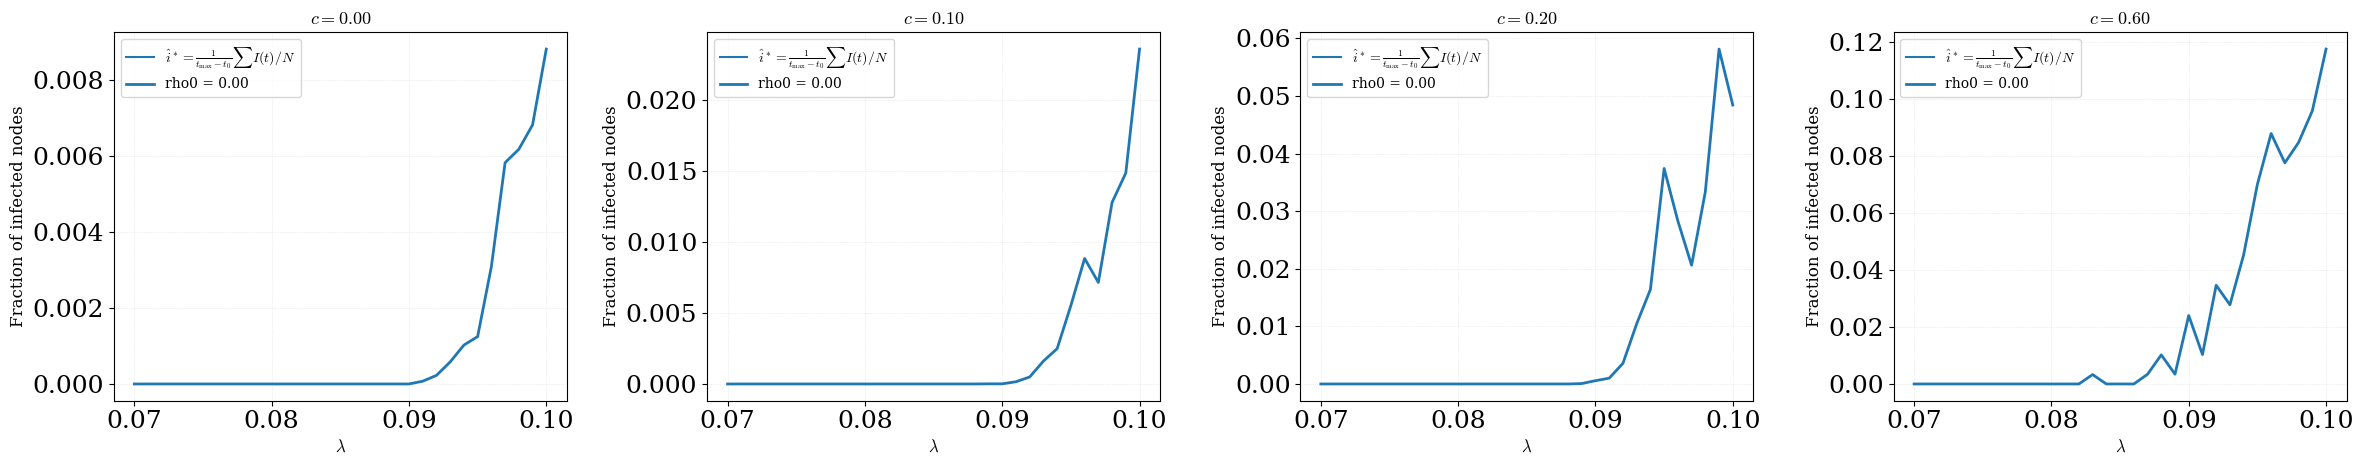

In [13]:
import numpy as np
import matplotlib.pyplot as plt

rho0_idx_list = [0]
t0 = int(tmax * 0.8)

fig, ax = plt.subplots(1, len(c_idx_list), figsize=(6 * len(c_idx_list), 5))

for idx, c_idx in enumerate(c_idx_list):
    c = c_values[c_idx]

    # 凡例用ダミー線（シンプルな式に）
    ax[idx].plot([], [], label=r"$\hat{i}^*=\frac{1}{t_{\max}-t_0}\sum I(t)/N$")

    # 平均値計算
    t0I = I[c_idx, :, :, :, t0:].mean(axis=-1).mean(axis=-1) / N

    for i, rho0_idx in enumerate(rho0_idx_list):
        ax[idx].plot(lambda_values, t0I[:, rho0_idx], color=colors[i], linewidth=2, label=f"rho0 = {rho0_values[rho0_idx]:.2f}")

    # タイトル（数式表記）
    ax[idx].set_title(rf"$c={c:.2f}$", fontsize=13)

    # 軸ラベル
    ax[idx].set_xlabel(r"$\lambda$", fontsize=12)
    ax[idx].set_ylabel("Fraction of infected nodes", fontsize=12)

    # ax[idx].set_ylim(0 - eps, 1 + eps)
    ax[idx].grid(True, which="both", alpha=0.25)

    leg = ax[idx].legend(frameon=True, fontsize=10)
    leg.get_frame().set_alpha(0.8)

plt.tight_layout()
plt.show()


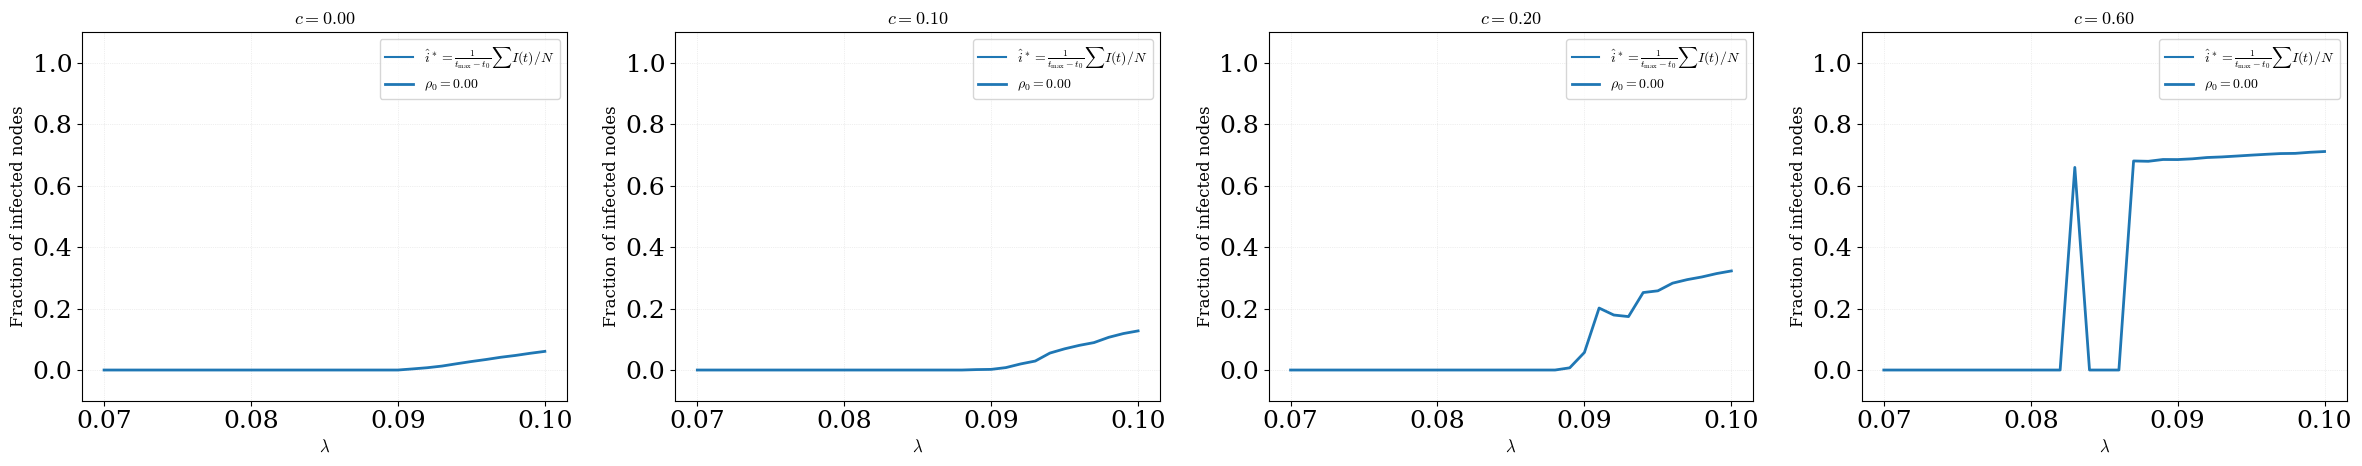

In [14]:
validI_ave = np.zeros((len(c_values), len(lambda_values), len(rho0_values)))
validI_num = np.zeros((len(c_values), len(lambda_values), len(rho0_values)))
threshold = 10

for c_idx in range(len(c_values)):
    for lambda_idx in range(len(lambda_values)):
        for rho0_idx in range(len(rho0_values)):
            for itr in range(total_itr):
                curI = I[c_idx, lambda_idx, rho0_idx, itr, t0:]
                if curI.mean(axis=-1) > threshold:
                    validI_ave[c_idx, lambda_idx, rho0_idx] += curI.mean(axis=-1)
                    validI_num[c_idx, lambda_idx, rho0_idx] += 1

for c_idx in range(len(c_values)):
    for lambda_idx in range(len(lambda_values)):
        for rho0_idx in range(len(rho0_values)):
                if validI_num[c_idx, lambda_idx, rho0_idx] > 0:
                    validI_ave[c_idx, lambda_idx, rho0_idx] /= validI_num[c_idx, lambda_idx, rho0_idx]

fig, ax = plt.subplots(1, len(c_idx_list), figsize=(6 * len(c_idx_list), 5))

for idx, c_idx in enumerate(c_idx_list):
    c = c_values[c_idx]

    # 凡例用ダミー線（シンプルな式に）
    ax[idx].plot([], [], label=r"$\hat{i}^*=\frac{1}{t_{\max}-t_0}\sum I(t)/N$")

    # 平均値計算
    for i, rho0_idx in enumerate(rho0_idx_list):
        ax[idx].plot(lambda_values, validI_ave[c_idx, :, rho0_idx] / N, color=colors[i], linewidth=2, label=rf"$\rho_0 = {rho0_values[rho0_idx]:.2f}$")

    # タイトル（数式表記）
    ax[idx].set_title(rf"$c={c:.2f}$", fontsize=13)

    # 軸ラベル
    ax[idx].set_xlabel(r"$\lambda$", fontsize=12)
    ax[idx].set_ylabel("Fraction of infected nodes", fontsize=12)

    ax[idx].set_ylim(0 - eps, 1 + eps)
    ax[idx].set_yticks(np.linspace(0, 1, 6))
    ax[idx].grid(True, which="both", alpha=0.25)

    leg = ax[idx].legend(frameon=True, fontsize=10)
    leg.get_frame().set_alpha(0.8)

plt.tight_layout()
plt.show()


In [ ]:
rho0_idx_list = [3, 4, 5, 6, 7, 8, 9, 10]

fig = plt.figure(figsize=(10, 6))

for idx, rho0_idx in enumerate(rho0_idx_list):
    rho0 = rho0_values[rho0_idx]
    plot_R = (((R[:, rho0_idx, :, -1]) ** 2).mean(axis=1) - (R[:, rho0_idx, :, -1]).mean(axis=1) ** 2) / ((R[:, rho0_idx, :, -1]).mean(axis=1) ** 2) 
    plt.plot(lambda_values, plot_R, label=f"rho0 = {rho0:.2f}", color=colors[idx])
    max_idx = np.argmax(plot_R)
    max_lambda = lambda_values[max_idx]
    max_R = plot_R[max_idx]
    plt.scatter(max_lambda, max_R, color=colors[idx], marker="x")
    plt.text(max_lambda, max_R, f"({max_lambda:.2f}, {max_R:.2f})", fontsize=10, ha="right", va="bottom")

plt.suptitle(rf"$\mathrm{{Relative\ Variance\ :}}\; \frac{{\left<R({tmax})^2\right> - \left<R({tmax})\right>^2}}{{\left<R({tmax})\right>^2}}$")
plt.legend()
plt.grid(True)
plt.xlabel(rf"$\lambda$")
plt.ylim(0, 5)
plt.show()

NameError: name 'R' is not defined

<Figure size 1000x600 with 0 Axes>

NameError: name 'rho0_min' is not defined

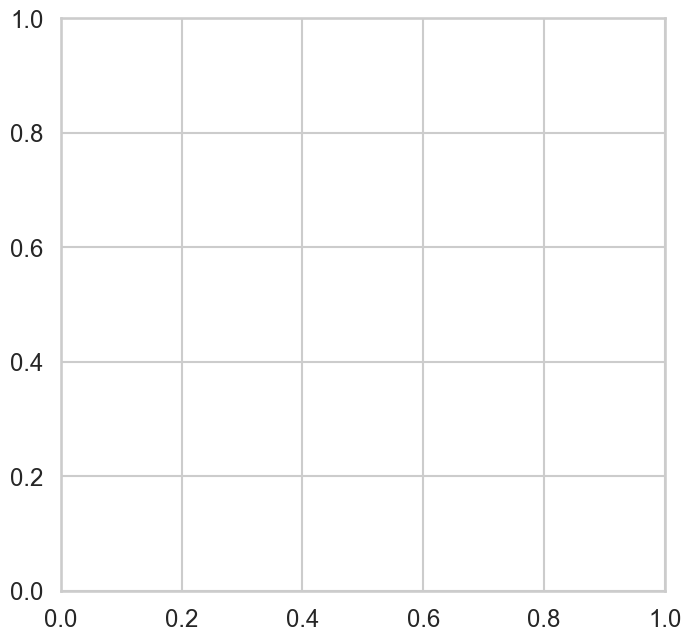

In [15]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns

# 見やすいサイズ＆字間
sns.set_context("talk", font_scale=1.05)
sns.set_style("whitegrid")

# ---- Figure ----
fig = plt.figure(figsize=(6.8, 6.3), constrained_layout=True)  # 余白調整はconstrained_layoutに任せる
gs = GridSpec(1, 1, figure=fig)

# 値のスケール（0〜1）
vmin, vmax = 0.0, 1.0

# ---- Heatmap ----
ax = fig.add_subplot(gs[0, 0])

# Rの最終時刻を平均して正規化（shape: [lambda, rho0] を想定）
heat = (validI_ave[2, :, :] / N)

im = ax.imshow(
    heat,
    extent=[rho0_min, rho0_max, lambda_min, lambda_max],   # x=rho0, y=lambda
    origin="lower",
    aspect="auto",
    cmap="magma",
    vmin=vmin, vmax=vmax,
    interpolation="nearest"
)

# タイトル：数式のイタリックを抑え、字間を適度に
title = (
    rf"$\mathrm{{{network_type}}}\;N={N},\;"
    rf"k_{{\mathrm{{ave}}}}={k_ave},\;c={c_values[c_idx]:.2f},\;"
    rf"\gamma={gamma:.2f}$"
)
ax.set_title(title, fontsize=18, pad=10)  # padでタイトルと軸の間隔を広げる

# 軸ラベル
ax.set_xlabel(r"$\rho_0$", fontsize=15)
ax.set_ylabel(r"$\lambda$", fontsize=15)

# 軸範囲きっちり（TeX表記の 0–1 に合わせる）
ax.set_xlim(rho0_min, rho0_max)
ax.set_ylim(lambda_min, lambda_max)

# 目盛りを0.1〜0.2刻みで綺麗に
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.tick_params(axis="both", which="major", labelsize=12)
ax.tick_params(axis="both", which="minor", length=3)

# グリッドは控えめに（minorも薄く）
ax.grid(linewidth=0.6, alpha=0.6)
ax.grid(which="minor", linewidth=0.4, alpha=0.3)

# ---- Colorbar：軸に紐づけてスマート配置 ----
# fractionで細さ、padで距離を調整。長すぎると感じたらshrinkを下げる
cbar = fig.colorbar(im, ax=ax, location="right", fraction=0.050, pad=0.04)
cbar.set_label(rf"$R({tmax})$", fontsize=15)
cbar.ax.tick_params(labelsize=11)
# ラベルを縦に・少し離す
cbar.set_label(r"$\hat{i}^*=\frac{1}{t_{\max}-t_0}\sum I(t)/N$", rotation=270, labelpad=40, fontsize=15)

plt.show()


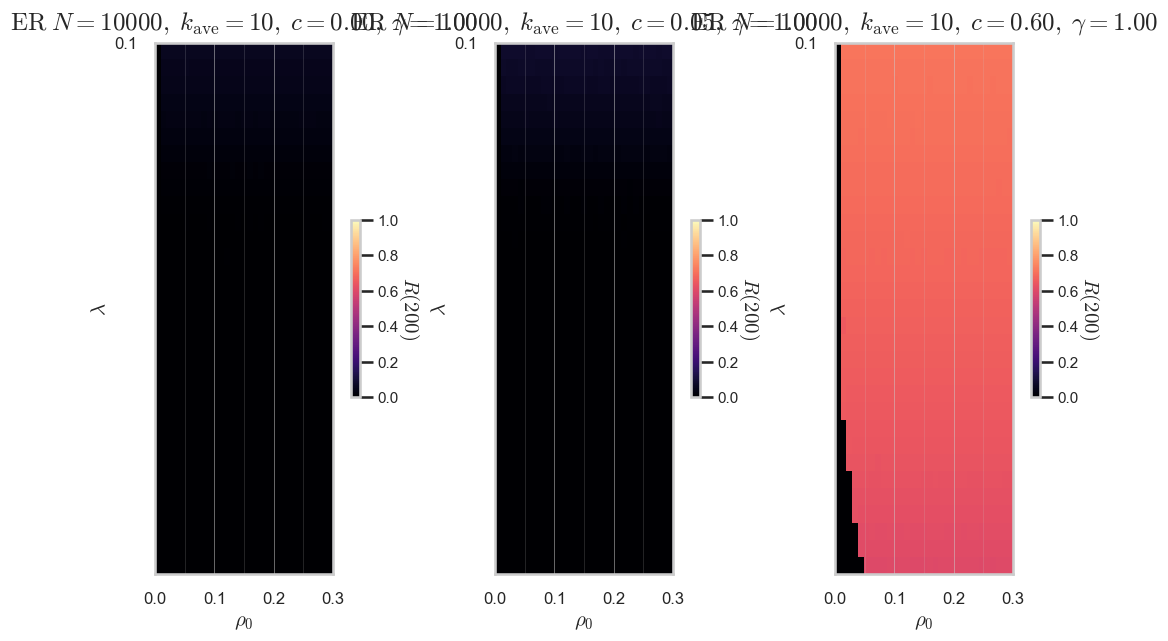

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns
import numpy as np

# 見やすいサイズ＆字間
sns.set_context("talk", font_scale=1.05)
sns.set_style("whitegrid")

# ---- Figure ----
fig = plt.figure(figsize=(6.8 * max(1, len(c_idx_list)/2), 6.3), constrained_layout=True)
gs = GridSpec(1, len(c_idx_list), figure=fig)

# 値のスケール（0〜1）: 全パネルで共通にする
vmin, vmax = 0.0, 1.0

for idx, c_idx in enumerate(c_idx_list):
    ax = fig.add_subplot(gs[0, idx])

    # Rの最終時刻を平均して正規化（shape: [lambda, rho0] を想定）
    # validI_ave の次元: [c, lambda, rho0]
    heat = validI_ave[c_idx, :, :] / N

    # 2Dヒートマップ（x=rho0, y=lambda）
    im = ax.imshow(
        heat,
        extent=[rho0_min, rho0_max, lambda_min, lambda_max],
        origin="lower",
        aspect="auto",
        cmap="magma",
        vmin=vmin, vmax=vmax,
        interpolation="nearest"
    )

    # タイトル
    title = (
        rf"$\mathrm{{{network_type}}}\;N={N},\;"
        rf"k_{{\mathrm{{ave}}}}={k_ave},\;c={c_values[c_idx]:.2f},\;"
        rf"\gamma={gamma:.2f}$"
    )
    ax.set_title(title, fontsize=18, pad=10)

    # 軸ラベル
    ax.set_xlabel(r"$\rho_0$", fontsize=15)
    ax.set_ylabel(r"$\lambda$", fontsize=15)

    # 軸範囲
    ax.set_xlim(rho0_min, rho0_max)
    ax.set_ylim(lambda_min, lambda_max)

    # 目盛り
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.tick_params(axis="both", which="minor", length=3)

    # グリッド
    ax.grid(linewidth=0.6, alpha=0.6)
    ax.grid(which="minor", linewidth=0.4, alpha=0.3)

    # ---- Colorbar（各軸ごと）----
    cbar = fig.colorbar(im, ax=ax, location="right", fraction=0.050, pad=0.04)
    cbar.set_label(rf"$R({tmax})$", rotation=270, labelpad=16, fontsize=15)
    cbar.ax.tick_params(labelsize=11)

plt.show()
